In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import RidgeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, roc_curve, auc

In [2]:
df_train = pd.read_csv("../data/train_lin.csv")
df_test = pd.read_csv("../data/test_lin.csv")

Split data into 5 folds for cross-validation

In [3]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
folds = [] # List of 5 tuples, each containing (train_fold, val_fold)
for train_index, val_index in skf.split(df_train.drop('label', axis=1), df_train['label']):
    train_fold = df_train.iloc[train_index]
    val_fold = df_train.iloc[val_index]
    folds.append((train_fold, val_fold))

Ridge Classifier

Best alpha: 10
Confusion Matrix:
TN: 20142, FP: 47
FN: 0, TP: 26970


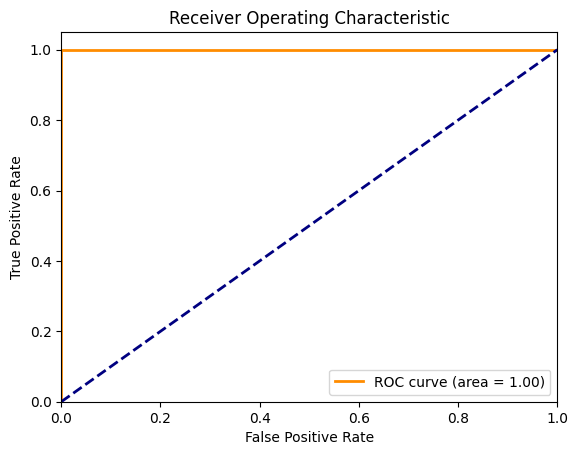

Accuracy: 0.9990033715727645
Precision: 0.9982603545915535
Recall: 1.0


In [4]:
# Define grid of alpha values
alphas = [0.01, 0.1, 1, 10, 100]

# Dictionary to store average validation accuracy for each alpha
alpha_scores = {}

for alpha in alphas:
    fold_scores = []
    for train_fold, val_fold in folds:
        X_train = train_fold.drop('label', axis=1)
        y_train = train_fold['label']
        X_val = val_fold.drop('label', axis=1)
        y_val = val_fold['label']
        
        model = RidgeClassifier(alpha=alpha)
        model.fit(X_train, y_train)
        y_pred_val = model.predict(X_val)
        acc = accuracy_score(y_val, y_pred_val)
        fold_scores.append(acc)
    
    alpha_scores[alpha] = sum(fold_scores) / len(fold_scores)

# Find the best alpha
best_alpha = max(alpha_scores, key=alpha_scores.get)
print(f"Best alpha: {best_alpha}")

# Fit the model on full training data with best alpha
X_full = df_train.drop('label', axis=1)
y_full = df_train['label']
model = RidgeClassifier(alpha=best_alpha)
model.fit(X_full, y_full)

# Predict on test data
X_test = df_test.drop('label', axis=1)
y_test = df_test['label']
y_pred_test = model.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_test)
print("Confusion Matrix:")
print(f"TN: {cm[0,0]}, FP: {cm[0,1]}")
print(f"FN: {cm[1,0]}, TP: {cm[1,1]}")

# Compute ROC curve and AUC
y_pred_proba = model.decision_function(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Compute and print metrics
accuracy = accuracy_score(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_test)
recall = recall_score(y_test, y_pred_test)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")


Logistic Regression with L2 Penalty

Best lambda: 0.01
Confusion Matrix:
TN: 20181, FP: 8
FN: 0, TP: 26970


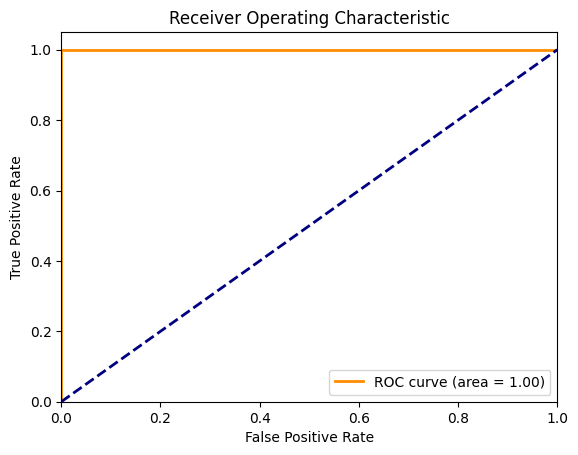

Accuracy: 0.9998303611187684
Precision: 0.9997034620802135
Recall: 1.0


In [5]:
lambdas = [0.01, 0.1, 1, 10, 100]

# Dictionary to store average validation accuracy for each lambda
lambda_scores = {}

for lambda_val in lambdas:
    fold_scores = []
    for train_fold, val_fold in folds:
        X_train = train_fold.drop('label', axis=1)
        y_train = train_fold['label']
        X_val = val_fold.drop('label', axis=1)
        y_val = val_fold['label']
        
        model = LogisticRegression(penalty='l2', C=1/lambda_val, random_state=42, max_iter=1000)
        model.fit(X_train, y_train)
        y_pred_val = model.predict(X_val)
        acc = accuracy_score(y_val, y_pred_val)
        fold_scores.append(acc)
    
    lambda_scores[lambda_val] = sum(fold_scores) / len(fold_scores)

# Find the best lambda
best_lambda = max(lambda_scores, key=lambda_scores.get)
print(f"Best lambda: {best_lambda}")

# Fit the model on full training data with best lambda
X_full = df_train.drop('label', axis=1)
y_full = df_train['label']
model = LogisticRegression(penalty='l2', C=1/best_lambda, random_state=42, max_iter=1000)
model.fit(X_full, y_full)

# Predict on test data
X_test = df_test.drop('label', axis=1)
y_test = df_test['label']
y_pred_test = model.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_test)
print("Confusion Matrix:")
print(f"TN: {cm[0,0]}, FP: {cm[0,1]}")
print(f"FN: {cm[1,0]}, TP: {cm[1,1]}")

# Compute ROC curve and AUC
y_pred_proba = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Compute and print metrics
accuracy = accuracy_score(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_test)
recall = recall_score(y_test, y_pred_test)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")

Lasso Regression (Logistic Regression with L1 penalty)

In [ ]:
lambdas = [0.01, 0.1, 1, 10, 100]

# Dictionary to store average validation accuracy for each lambda
lambda_scores = {}

for lambda_val in lambdas:

    # Dictionary to store average validation accuracy for each lambda
    lambda_scores = {}

    for lambda_val in lambdas:
        fold_scores = []
        for train_fold, val_fold in folds:
            X_train = train_fold.drop('label', axis=1)
            y_train = train_fold['label']
            X_val = val_fold.drop('label', axis=1)
            y_val = val_fold['label']
            
            model = LogisticRegression(penalty='l1', solver='saga', C=1/lambda_val, random_state=42, max_iter=1000)
            model.fit(X_train, y_train)
            y_pred_val = model.predict(X_val)
            acc = accuracy_score(y_val, y_pred_val)
            fold_scores.append(acc)
        
        lambda_scores[lambda_val] = sum(fold_scores) / len(fold_scores)

    # Find the best lambda
    best_lambda = max(lambda_scores, key=lambda_scores.get)
    print(f"Best lambda: {best_lambda}")

    # Fit the model on full training data with best lambda
    X_full = df_train.drop('label', axis=1)
    y_full = df_train['label']
    model = LogisticRegression(
        penalty='l1',
        solver='saga',
        C=1/best_lambda,
        random_state=42,
        max_iter=1000
    )
    model.fit(X_full, y_full)

    # Predict on test data
    X_test = df_test.drop('label', axis=1)
    y_test = df_test['label']
    y_pred_test = model.predict(X_test)

    # Compute confusion matrix
    cm = confusion_matrix(y_test, y_pred_test)
    print("Confusion Matrix:")
    print(f"TN: {cm[0,0]}, FP: {cm[0,1]}")
    print(f"FN: {cm[1,0]}, TP: {cm[1,1]}")

    # Compute ROC curve and AUC
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()

    # Compute and print metrics
    accuracy = accuracy_score(y_test, y_pred_test)
    precision = precision_score(y_test, y_pred_test)
    recall = recall_score(y_test, y_pred_test)

    print(f"Accuracy: {accuracy}")
    print(f"Precision: {precision}")
    print(f"Recall: {recall}")
    for train_fold, val_fold in folds:
        X_train = train_fold.drop('label', axis=1)
        y_train = train_fold['label']
        X_val = val_fold.drop('label', axis=1)
        y_val = val_fold['label']
        
        model = LogisticRegression(penalty='l1', C=1/lambda_val, random_state=42, max_iter=1000)
        model.fit(X_train, y_train)
        y_pred_val = model.predict(X_val)
        acc = accuracy_score(y_val, y_pred_val)
        fold_scores.append(acc)
    
    lambda_scores[lambda_val] = sum(fold_scores) / len(fold_scores)

# Find the best lambda
best_lambda = max(lambda_scores, key=lambda_scores.get)
print(f"Best lambda: {best_lambda}")

# Fit the model on full training data with best lambda
X_full = df_train.drop('label', axis=1)
y_full = df_train['label']
model = LogisticRegression(
    penalty='l1',
    solver='saga',
    C=1/best_lambda,
    random_state=42,
    max_iter=1000
)
model.fit(X_full, y_full)

# Predict on test data
X_test = df_test.drop('label', axis=1)
y_test = df_test['label']
y_pred_test = model.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_test)
print("Confusion Matrix:")
print(f"TN: {cm[0,0]}, FP: {cm[0,1]}")
print(f"FN: {cm[1,0]}, TP: {cm[1,1]}")

# Compute ROC curve and AUC
y_pred_proba = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Compute and print metrics
accuracy = accuracy_score(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_test)
recall = recall_score(y_test, y_pred_test)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")

c:\Users\Yun Tsing\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Elastic Net 

Best lambda: 0.01, Best l1_ratio: 0.5
Best CV accuracy: 0.999258
Confusion Matrix:
TN: 20144, FP: 45
FN: 0, TP: 26970


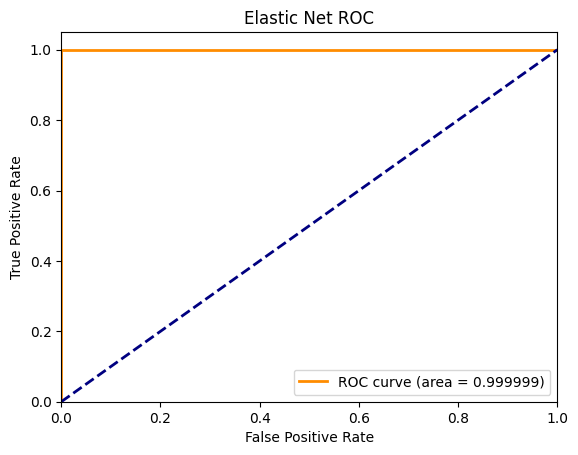

Accuracy: 0.999046
Precision: 0.998334
Recall: 1.000000


In [ ]:
lambdas = [0.01, 0.1, 1, 10, 100]
l1_ratios = [0.1, 0.5, 0.9]

elasticnet_scores = {}  # key: (lambda_val, l1_ratio)

for lambda_val in lambdas:
    for l1_ratio in l1_ratios:
        fold_scores = []
        for train_fold, val_fold in folds:
            X_train = train_fold.drop('label', axis=1)
            y_train = train_fold['label']
            X_val = val_fold.drop('label', axis=1)
            y_val = val_fold['label']

            model_en = SGDClassifier(
                loss='log_loss',        
                penalty='elasticnet',
                alpha=lambda_val,       
                l1_ratio=l1_ratio,
                random_state=42,
                max_iter=1000,
                tol=1e-3,
                n_jobs=-1
            )
            model_en.fit(X_train, y_train)
            y_pred_val = model_en.predict(X_val)
            fold_scores.append(accuracy_score(y_val, y_pred_val))

        elasticnet_scores[(lambda_val, l1_ratio)] = sum(fold_scores) / len(fold_scores)

best_lambda, best_l1_ratio = max(elasticnet_scores, key=elasticnet_scores.get)
print(f"Best lambda: {best_lambda}, Best l1_ratio: {best_l1_ratio}")
print(f"Best CV accuracy: {elasticnet_scores[(best_lambda, best_l1_ratio)]:.6f}")

X_full = df_train.drop('label', axis=1)
y_full = df_train['label']
model_en = SGDClassifier(
    loss='log_loss',
    penalty='elasticnet',
    alpha=best_lambda,
    l1_ratio=best_l1_ratio,
    random_state=42,
    max_iter=1000,
    tol=1e-3,
    n_jobs=-1
)
model_en.fit(X_full, y_full)

X_test = df_test.drop('label', axis=1)
y_test = df_test['label']
y_pred_test = model_en.predict(X_test)

cm = confusion_matrix(y_test, y_pred_test)
print("Confusion Matrix:")
print(f"TN: {cm[0,0]}, FP: {cm[0,1]}")
print(f"FN: {cm[1,0]}, TP: {cm[1,1]}")

y_pred_proba = model_en.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.6f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Elastic Net ROC')
plt.legend(loc="lower right")
plt.show()

accuracy = accuracy_score(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_test)
recall = recall_score(y_test, y_pred_test)

print(f"Accuracy: {accuracy:.6f}")
print(f"Precision: {precision:.6f}")
print(f"Recall: {recall:.6f}")